In [1]:
library(tidyverse)
library(dbplyr)
library(bigrquery)
library(lubridate)

bq_auth()

project_id = "yhcr-prd-bradfor-bia-core"

# create connection to database
con <- DBI::dbConnect(bigrquery::bigquery(), 
                      project = project_id)

print(paste0("Connected to : ", project_id))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




[1] "Connected to : yhcr-prd-bradfor-bia-core"


In [2]:
person_ids <- read.csv('data/additional_person_ids.csv', header = TRUE)

In [3]:
pupil_data = "CB_2489.cb_KS4Pupil_All"

In [4]:


#pupil_table <- tbl(con, pupil_data) |>
    select(person_id, KS4_ATT8,KS4_P8SCORE, 
           KS4_ENTRIES, KS4_ENTRY_E_ALL_PTQ_EE,
           KS4_ENTRY_1_3NG_PTQ_EE, KS4_ENTRY_5_3NG_PTQ_EE, 
           KS4_PASS_LEV1_PTQ_EE, 
           KS4_BTEC_PTQ_EE, KS4_VOCQUAL_PTQ_EE,
           KS4_ANYPASS_PTQ_EE, 
           KS4_FINELEVEL_PTQ_EE,
           KS4_IDACI) 

In [5]:
#entries_table <- tbl(con, pupil_data) |>
    select(person_id, KS4_ATT8,
           KS4_ENTRIES, KS4_ENTRY_E_ALL_PTQ_EE,
           KS4_KS2EMFG
           ) 

In [4]:
ks4_table <- tbl(con, pupil_data) |>
    select(person_id,  
           KS4_ENTRIES, 
           KS4_PASS_LEV1_PTQ_EE, 
           KS4_PASS_LEV2_PTQ_EE,
           KS4_IDACI) 

In [7]:
#entries_df <- collect(entries_table)

In [8]:
#pupil_df <- collect(pupil_table)

In [5]:
ks4_df <- collect(ks4_table)

In [10]:
#head(pupil_df)

person_id,KS4_ATT8,KS4_P8SCORE,KS4_ENTRIES,KS4_ENTRY_E_ALL_PTQ_EE,KS4_ENTRY_1_3NG_PTQ_EE,KS4_ENTRY_5_3NG_PTQ_EE,KS4_PASS_LEV1_PTQ_EE,KS4_BTEC_PTQ_EE,KS4_VOCQUAL_PTQ_EE,KS4_ANYPASS_PTQ_EE,KS4_FINELEVEL_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5155E920BFE1B3D9F17E11F1C971EC8B1D7D17F0434C5DDA9A6B471F65069772,NA,NA,10,NA,NA,NA,NA,NA,NA,NA,NA,NA
33123AC91CA48A233EF78F6071277769B94FFB2F4395DC494559B677DC50DF7A,NA,NA,18,NA,NA,NA,NA,NA,NA,NA,NA,NA
3C1A4A6804FDFB4CEAB84D6B755649E364B05AABECB1E1C0DC85E2645B73FE71,NA,NA,1,NA,NA,NA,NA,NA,NA,NA,NA,NA
71F5932CCDF614111A5E5ABA8DF88F1AFC1A1CA0B1646710488CE3DCE86A8601,NA,NA,14,NA,NA,NA,NA,NA,NA,NA,NA,NA
C5BC4DF86AB485EB962FC6FC9B7E2534E8A393D4A9D0C30186FA42AC1ECC43E8,NA,NA,16,NA,NA,NA,NA,NA,NA,NA,NA,NA
87DFA098EA880CF6BDC3B0C87FFC9BEBE08FF7276818BA9960B719B8448FA301,NA,NA,14,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [6]:
head(ks4_df)

person_id,KS4_ENTRIES,KS4_PASS_LEV1_PTQ_EE,KS4_PASS_LEV2_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
59DEF54CF283E8EF68E798321E059001B5576467D4C522AE50C66E98C3347BE4,1,NA,NA,NA
FE8DEF4A661E2487751B3AD508752C44ADD74ADF94D3CEF99C2850ADE849FB3C,1,NA,NA,NA
1FD14B89003C79F213467F74287BE5BBDBC1AED8CCE3917A2995353D85A45E2D,1,NA,NA,NA
16F834658BDB27B6597486DF32C73638E6BAD19DD5ED17A604BBE9C21DB9608A,24,NA,NA,NA
51D548597E0DD98F8D364C50E140F3DE28C6B4463A5B313F2E7B91C304227C9F,2,NA,NA,NA
01859BCF01FBB389CDF2978CF79AA19B8020F43A2D321F9C78ADC0ED3B7CE735,1,NA,NA,NA


# Explore variables

KS4_ENTRIES: Total number of GCSE and equivalents entries (GCSE equivalencies). 

KS4_ENTRY_E_ALL_PTQ_EE: Total number of GCSE and equivalents entries (all S96 quals) under current methodology but all qualifications (ignore PTQ_INCLUDE flag)

KS4_KS2EMFG: KS2 prior attainment in English and mathematics

KS4_ENTRY_1_3NG_PTQ_EE: entered into at least 1 GCSE or equivalent. 
KS4_ENTRY_5_3NG_PTQ_EE: " 5

KS4_PASS_LEV1_PTQ_EE: Total number of Level 1 GCSE and equivalent qualifications (GCSE equivalencies). Level 1 qualifications, often achieved in Years 10 and 11 of secondary school, are equivalent to GCSE grades 1, 2, or 3 (formerly D, E, F, or G) and include qualifications like Level 1 Functional Skills or Essential Skills. 

KS4_PASS_LEV2_PTQ_EE: Total number of Level 2 GCSE and equivalent qualifications (GCSE equivalencies). Level 2 qualifications, equivalent to GCSE grades 9-4 (or A*-C in the old system), include Functional Skills Level 2, NVQ Level 2, and intermediate apprenticeships, among others. 

KS4_ANYPASS_PTQ_EE: Achieved any passes at all in GCSE or equivalents(inc S96, WOLF, first Entry and vocational qualification capping)

KS4_VOCQUAL_PTQ_EE: Flag to indicate if a learner has achieved at least one vocational qualification at KS4. 

KS4_BTEC_PTQ_EE: Number of BTECs achieved (NOT GCSE equivalencies).

KS4_FINELEVEL_PTQ_EE: Pupil Fine Level score

In [12]:
#pupil_filtered <- pupil_df |>
#    filter(person_id %in% person_ids$person_id) 

In [13]:
#entries_filtered <- entries_df |>
#    filter(person_id %in% person_ids$person_id) 

In [7]:
ks4_filtered <- ks4_df |>
    filter(person_id %in% person_ids$person_id) 

In [8]:
#entries_filtered |> arrange(KS4_ATT8)

In [9]:
#pupil_filtered |> arrange(KS4_ATT8)

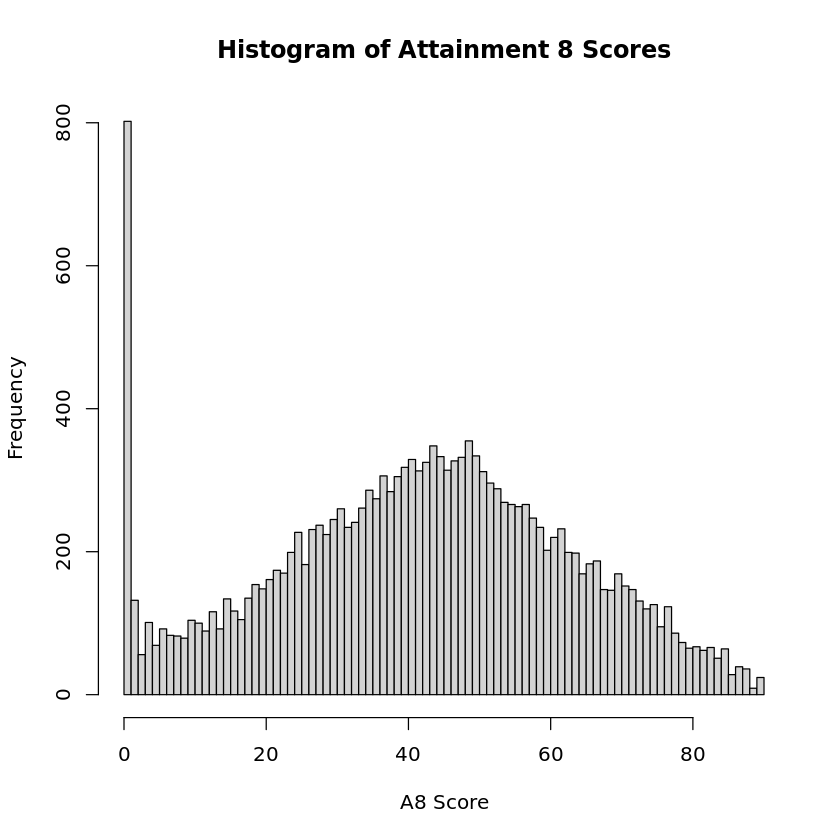

In [17]:
hist(pupil_filtered$KS4_ATT8, breaks = 100,
    main = "Histogram of Attainment 8 Scores", 
     xlab = "A8 Score")

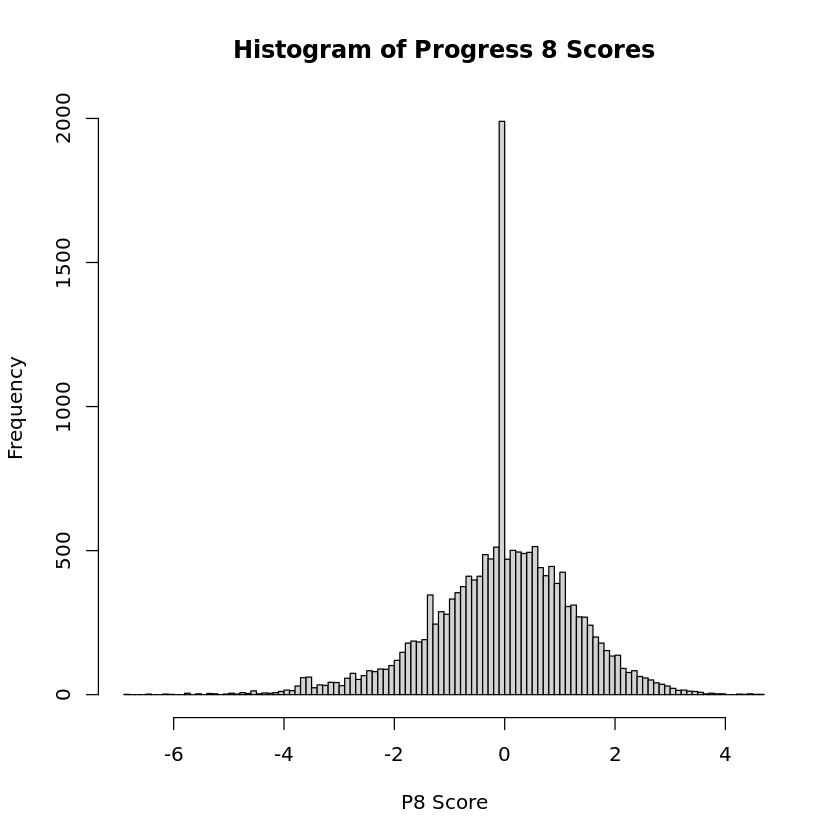

In [18]:
hist(pupil_filtered$KS4_P8SCORE, breaks = 100,
    main = "Histogram of Progress 8 Scores", 
     xlab = "P8 Score")

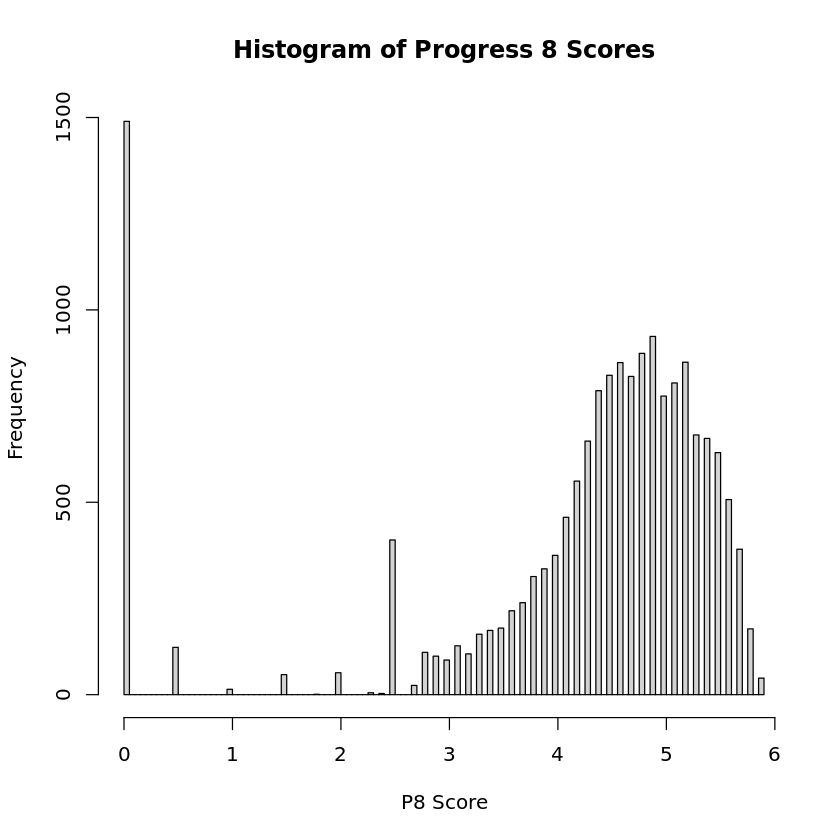

In [19]:
hist(pupil_filtered$KS4_FINELEVEL_PTQ_EE, breaks = 100,
    main = "Histogram of Progress 8 Scores", 
     xlab = "P8 Score")

In [10]:
#head(entries_filtered)

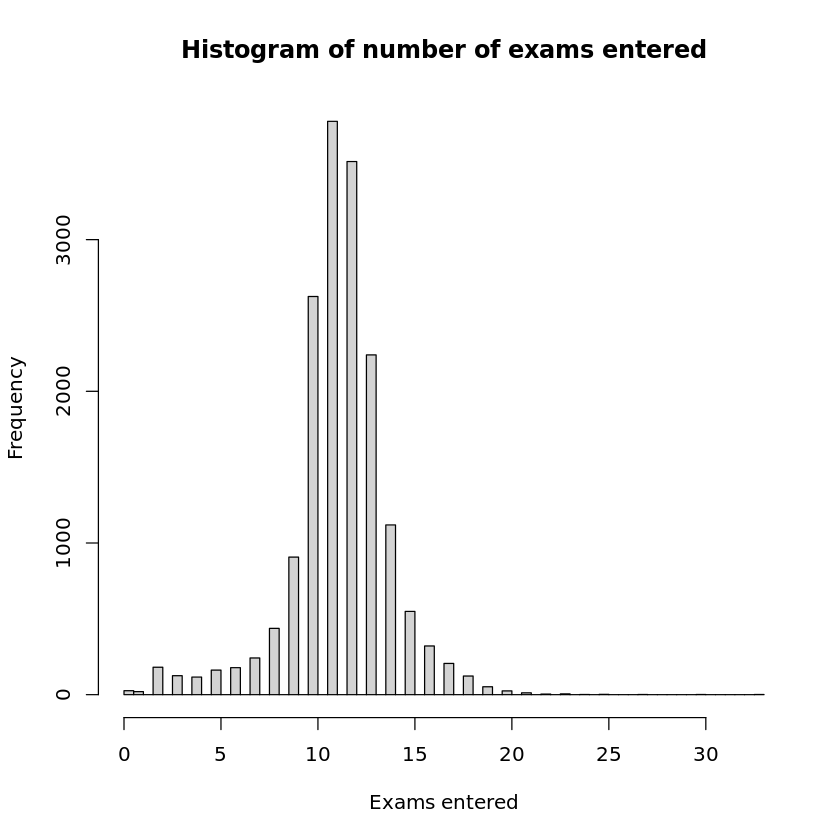

In [21]:
hist(entries_filtered$KS4_ENTRIES, breaks = 100,
    main = "Histogram of number of exams entered", 
     xlab = "Exams entered")

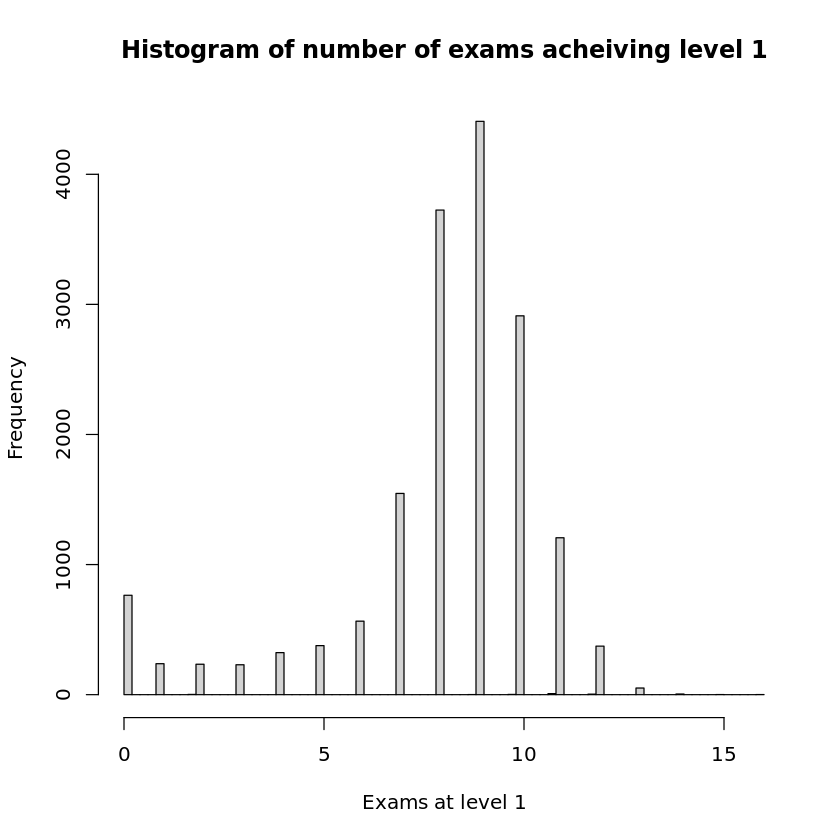

In [22]:
hist(pupil_filtered$KS4_PASS_LEV1_PTQ_EE, breaks = 100,
    main = "Histogram of number of exams acheiving level 1", 
     xlab = "Exams at level 1")

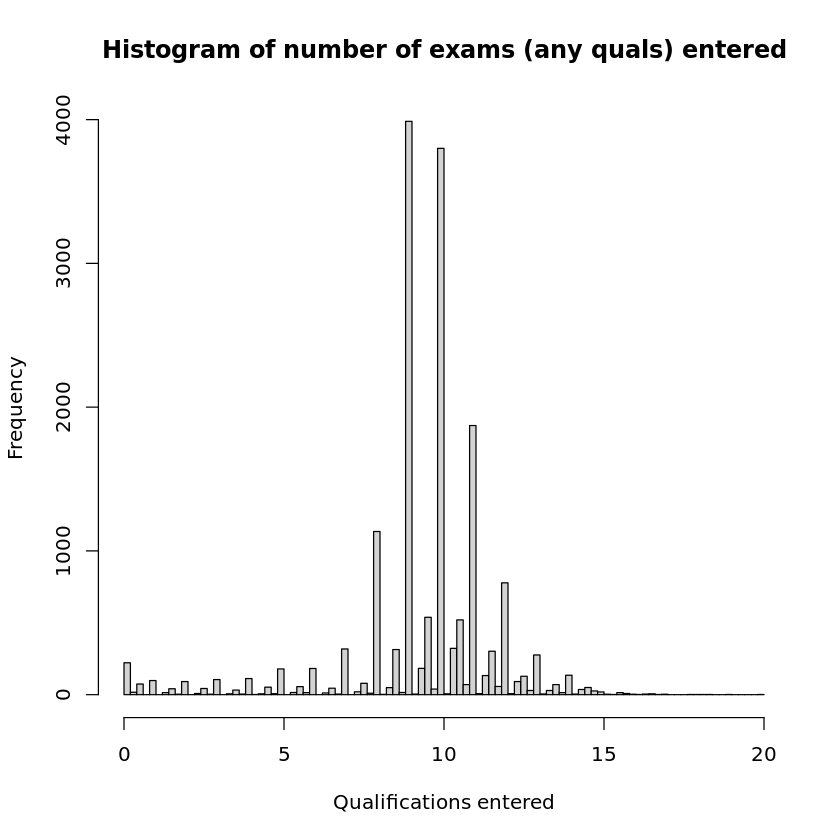

In [23]:
hist(entries_filtered$KS4_ENTRY_E_ALL_PTQ_EE, breaks = 100,
    main = "Histogram of number of exams (any quals) entered", 
     xlab = "Qualifications entered")

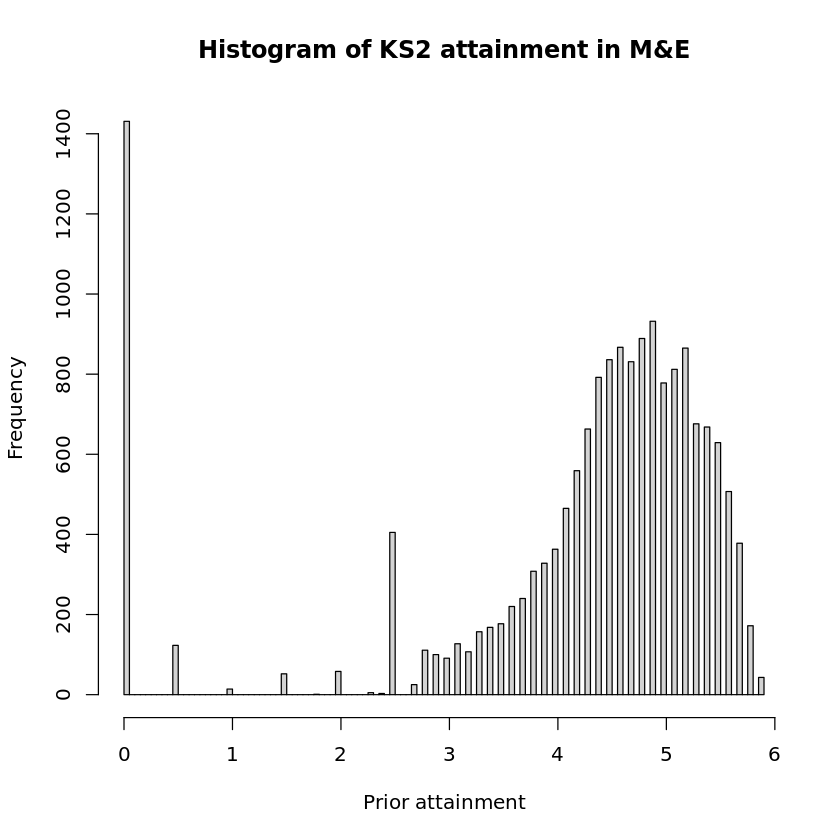

In [24]:
hist(entries_filtered$KS4_KS2EMFG, breaks = 100,
    main = "Histogram of KS2 attainment in M&E", 
     xlab = "Prior attainment")

# Visualise

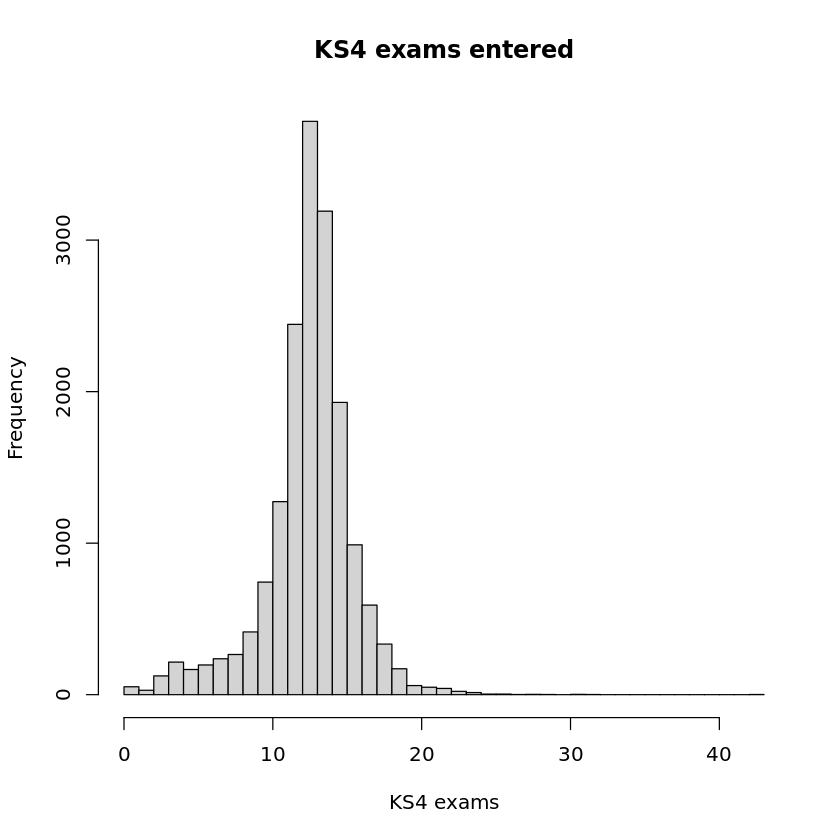

In [11]:
hist(ks4_filtered$KS4_ENTRIES, breaks = 33,
    main = "KS4 exams entered", 
     xlab = "KS4 exams")

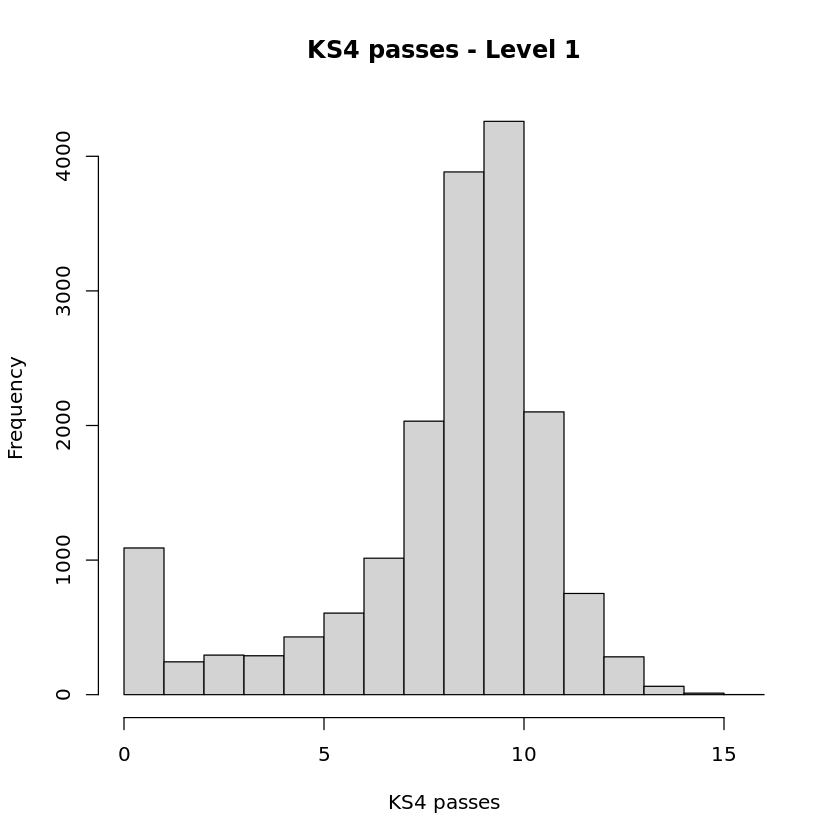

In [12]:
hist(ks4_filtered$KS4_PASS_LEV1_PTQ_EE, breaks = 16,
    main = "KS4 passes - Level 1", 
     xlab = "KS4 passes")

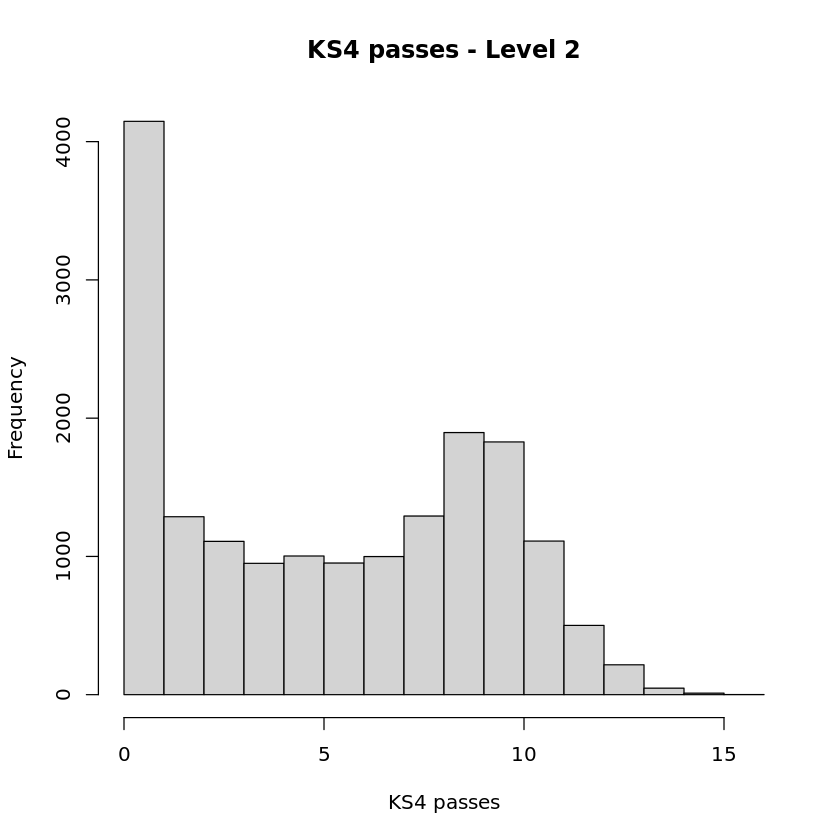

In [13]:
hist(ks4_filtered$KS4_PASS_LEV2_PTQ_EE, breaks = 16,
    main = "KS4 passes - Level 2", 
     xlab = "KS4 passes")

In [14]:
summary(ks4_filtered)

  person_id          KS4_ENTRIES    KS4_PASS_LEV1_PTQ_EE KS4_PASS_LEV2_PTQ_EE
 Length:17350       Min.   : 0.00   Min.   : 0.000       Min.   : 0.000      
 Class :character   1st Qu.:12.00   1st Qu.: 8.000       1st Qu.: 2.000      
 Mode  :character   Median :13.00   Median : 9.000       Median : 6.000      
                    Mean   :12.91   Mean   : 8.434       Mean   : 5.554      
                    3rd Qu.:14.00   3rd Qu.:10.000       3rd Qu.: 9.000      
                    Max.   :43.00   Max.   :16.000       Max.   :16.000      
   KS4_IDACI     
 Min.   :0.0000  
 1st Qu.:0.1000  
 Median :0.2400  
 Mean   :0.2398  
 3rd Qu.:0.3600  
 Max.   :0.8900  

#### exploring students who are recorded to have entered different numbers of exams...

In [15]:
ks4_filtered %>%
  count(person_id) %>%
  filter(n > 1)

person_id,n
<chr>,<int>
0045ADA48CA299BC4445318E8D951610DCB89A829665CFC821E92340F0F8B30D,2
00D0DCE31E1E532A9AD051B9A03E286EE87258F21A7AC2C7EC65C9A2F2C3D6BB,2
02A94A7A9495B9095F902B7CEB7D30786B0F18A522DBF8ABCF55CCC01CF28ED0,2
07C3B375AE8CD966385763D87E4BA2570FEF4FA57A12B8F3DFAE9E1CA1B1331B,2
08F5708257B005D8855265D7B8DE46F4E76C03F31E03DA5898FE6091F4494353,2
0A8AEA02880A1B827AAC47CED35528572C04E37A40B85C33A9502CEB1D14E4E6,2
0B7025E336432FC99B4806EEE7534410466BB66D808B8BC4B244D2378B519B16,2
0BE8902A22ADF0A4296C03C4E09ABDAD1A99EE1648858294392507E7E28BED94,2
0CA2CED12CD3779ED57DFCE2E02DFECCFBF5E35A067D826B8CC0791F265EAEC6,2


In [16]:
ks4_filtered <- ks4_filtered |>
  group_by(person_id) |>
  filter(n() == 1 | KS4_ENTRIES == min(KS4_ENTRIES)) |>
  ungroup()

In [17]:
ks4_filtered

person_id,KS4_ENTRIES,KS4_PASS_LEV1_PTQ_EE,KS4_PASS_LEV2_PTQ_EE,KS4_IDACI
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
999E2FF4F0303428E1280117A02BCEC59A7B8D4CBDD61036F4760B51016F8241,2,0,0,0.00
69EF02A9067140DD81019ED940F066239896FA631C2C5AF68A8AA9D5B452393D,0,0,0,0.00
445119E057D1EB3EE45B61EDF26220F6B81154AE021CDB2070F3E655C926F859,2,0,0,0.00
718BA2DE45FA4B9A5D6C3FFB29F57237AB9CF920FBB68375A8FFDCC9B3BF4BE6,1,0,0,0.00
D4AD86463720A23BBFB0C45C8891896EE343963A9A1D09FECCD11A08A9B9BD8C,1,0,0,0.00
83EDFB835D4D45BA03DF5E77E77D633903DF918A876C1D24F249AE67E152C5C3,2,1,0,0.00
F0B3478ECB0D5A7CBA60845C92DDAEEAB27A8603F392D6A2F38BAB5104FC4F35,1,0,0,0.00
AB3701ED6BAF1FBC2E9D027C3D0CF2621FC26A211267B3A730107DF225EAF03B,2,0,0,0.00
39F4C658BA14F93DBBAC4ED5F6EFDE0FC00E4D4506D4A76E2EC884A805C5A9B9,0,0,0,0.00


# Save to csv

In [18]:
write.csv(ks4_filtered, "data/additional_ks4_filtered.csv", row.names = FALSE)